# Sticky-strike vs sticky-moneyness PCA

This notebook is the comparison behind the headline framework choice: the factor model
(`pca_factors.ipynb`) works in **sticky-strike** coordinates, and here is why.

The alternative is fitting PCA to surface changes at **fixed (TTM, moneyness)** —
*sticky-moneyness* coordinates. Its natural target is the `vol_surface` piece of the
attribution (daily std **$150k**), with the spot-driven smile slide (std $124k, corr −0.89
with the surface piece) left to the equity bucket via the smile delta. The option's own
fixed-strike vol change — attribution `vol` less term roll, std **$70k** — is then the
*difference* of those two big offsetting pieces.

In **sticky-strike** coordinates each pillar (τ, m) tracks the fixed strike K = m% of the
*previous* close, so its daily change samples the new surface at moneyness m·S₀/S₁:

$$\Delta\sigma^{ss}_{ij} \;=\; \sigma_t\!\left(\tau_i,\; m_j \tfrac{S_0}{S_1}\right) - \sigma_{t-1}(\tau_i, m_j)$$

i.e. surface change **plus smile slide**, term roll excluded. The rescaled point is sampled
with the same bicubic interpolant pricing uses (`sticky_strike_dsigma(sd, interp="cubic")`,
the default; `"linear"` and shape-preserving `"pchip"` are available — sampling smoothness
matters, see the estimate-quality section). Both fits use the same weights (the book's mean
|bucket vega|) and the same fit sample, so every difference below is purely the coordinate
change.

The two coordinate systems imply different delta pairings — each pair is complete, with no
double counting inside it:

| vol coordinates | Δσ contains | paired delta | fixed-strike vol P&L target |
|---|---|---|---|
| sticky-moneyness | surface move only | smile delta (slide in equity) | `vol_surface` + slide handed over |
| sticky-strike | surface move + slide | plain BS delta | `vol − vol_roll` directly |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from vol_pca import load_surfaces, simulate_book, fit_pca, factor_vega_estimates
from vol_pca.factors import factor_scores, sticky_strike_dsigma
from vol_pca.attribution import independent_attribution
from vol_pca.surface import TTM_PILLARS, MONEYNESS

C_MON, C_SS, C_AUX = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUT = "#0b0b0b", "#898781"
DIV_CMAP = LinearSegmentedColormap.from_list("bwr_soft", ["#2a78d6", "#f0efec", "#e34948"])
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "text.color": "#0b0b0b", "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.figsize": (10, 4.2), "figure.dpi": 110,
    "legend.frameon": False,
})
TTM_LBL = ["1M", "2M", "3M", "4M", "6M", "8M", "10M", "12M"]
MON_LBL = [str(int(m)) for m in MONEYNESS]
nt, nm = len(TTM_PILLARS), len(MONEYNESS)

sd = load_surfaces("SPX_volSurface 2.csv")
book, bucket_vega, dsigma = simulate_book(sd)
dsigma_ss = sticky_strike_dsigma(sd)
attr, _ = independent_attribution(sd)
normal = (book["gap_days"] <= 7).to_numpy()
ret = np.diff(np.log(sd.spot))

vega_w = np.abs(bucket_vega[normal]).mean(axis=0)
m_mon = fit_pca(dsigma, fit_mask=normal, weights=vega_w)
m_ss = fit_pca(dsigma_ss, fit_mask=normal, weights=vega_w)
for m in (m_mon, m_ss):                       # sign convention as in pca_factors
    for i in range(6):
        pat = m.components[i] / m.weights
        if pat[np.argmax(np.abs(pat))] < 0:
            m.components[i] *= -1

t_mon = attr["vol_surface"].to_numpy()        # own target, sticky-moneyness PCA
t_ss = (attr["vol"] - attr["vol_roll"]).to_numpy()   # own target, sticky-strike PCA
slide = attr["vol_slide"].to_numpy()

print(f"targets (daily std, normal days): vol_surface ${t_mon[normal].std():,.0f}   "
      f"fixed-strike vol ex roll ${t_ss[normal].std():,.0f}")
print(f"corr(vol_surface, vol_slide) = "
      f"{np.corrcoef(t_mon[normal], slide[normal])[0, 1]:.3f}")

targets (daily std, normal days): vol_surface $149,892   fixed-strike vol ex roll $69,712
corr(vol_surface, vol_slide) = -0.887


## How big are daily moves in each coordinate system?

Near the money the skew slide cancels most of the level move: **sticky-strike ATM pillar moves
are roughly half the size** of the fixed-moneyness ones — the classic observation that SPX
daily dynamics sit much closer to sticky-strike than to sticky-moneyness. The cancellation
fades away from the money (ratio above 1 around the 120–140 call columns, up to ~1.2), and
the 50 edge column is slightly damped by the lookup clamping at the quoted grid boundary.

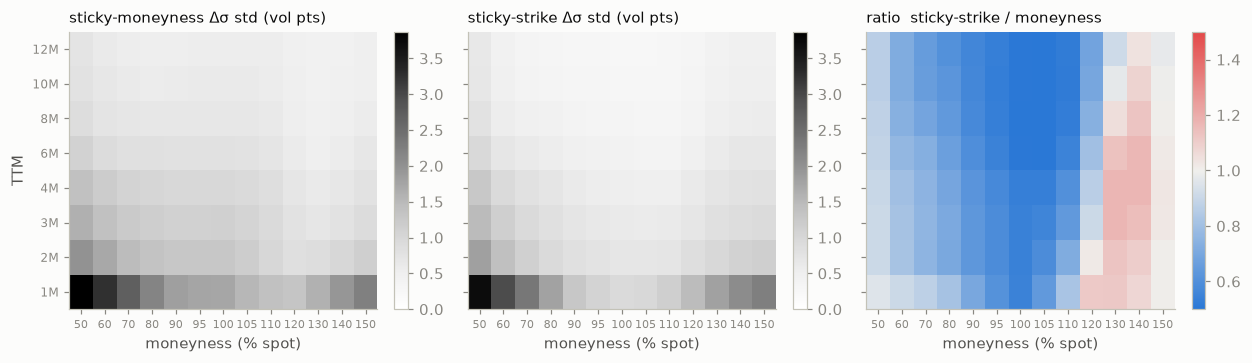

ATM (100%) daily vol-move std by TTM (vol pts):
     moneyness  sticky-strike  ratio
1M       1.728          0.943  0.546
2M       1.270          0.689  0.542
3M       1.105          0.599  0.542
4M       0.981          0.522  0.532
6M       0.788          0.399  0.507
8M       0.674          0.340  0.504
10M      0.597          0.301  0.504
12M      0.536          0.271  0.505


In [2]:
std_mon = dsigma[normal].std(axis=0).reshape(nt, nm) * 100
std_ss = dsigma_ss[normal].std(axis=0).reshape(nt, nm) * 100
vmax = max(std_mon.max(), std_ss.max())

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4), sharey=True)
for ax, pat, title, kw in (
        (axes[0], std_mon, "sticky-moneyness Δσ std (vol pts)", dict(cmap="Greys", vmin=0, vmax=vmax)),
        (axes[1], std_ss, "sticky-strike Δσ std (vol pts)", dict(cmap="Greys", vmin=0, vmax=vmax)),
        (axes[2], std_ss / std_mon, "ratio  sticky-strike / moneyness", dict(cmap=DIV_CMAP, vmin=0.5, vmax=1.5))):
    im = ax.imshow(pat, origin="lower", aspect="auto", **kw)
    ax.set_xticks(range(nm), MON_LBL, fontsize=7)
    ax.set_yticks(range(nt), TTM_LBL, fontsize=8)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_xlabel("moneyness (% spot)")
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046)
axes[0].set_ylabel("TTM")
plt.tight_layout(); plt.show()

atm = list(MONEYNESS).index(100.0)
tab = pd.DataFrame({"moneyness": std_mon[:, atm], "sticky-strike": std_ss[:, atm],
                    "ratio": std_ss[:, atm] / std_mon[:, atm]}, index=TTM_LBL)
print("ATM (100%) daily vol-move std by TTM (vol pts):")
print(tab.round(3).to_string())

## Factor shapes

Same vega-weighted fit, so both models spend their capacity where the book's dollar vega is.
PC1 is a level factor in both, but the sticky-strike version has **half the ATM amplitude and a
much flatter smile profile** — the skewed part of the level move is exactly what slide cancels.
Variance is also less concentrated: PC1 carries 94.2% of the $-weighted variance vs 98.3% in
moneyness coordinates, with PC2 (short-end + wings) and PC3 (call wing) picking up the rest.

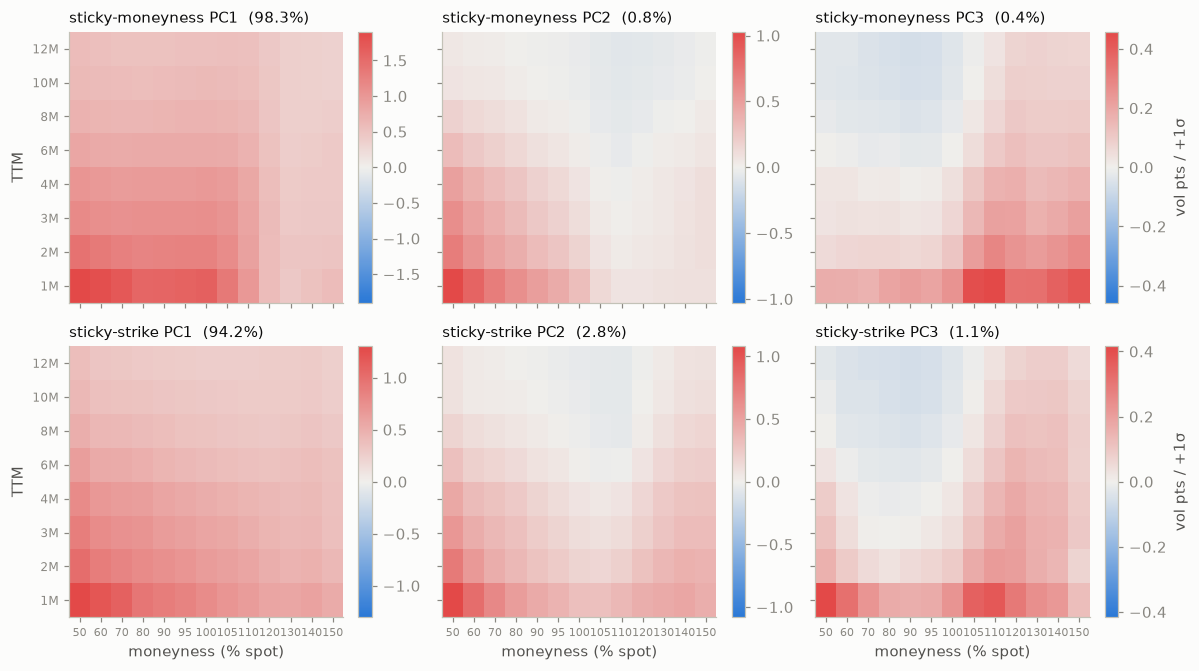

In [3]:
f_mon = factor_scores(dsigma, m_mon)
f_ss = factor_scores(dsigma_ss, m_ss)

fig, axes = plt.subplots(2, 3, figsize=(11, 6.2), sharex=True, sharey=True)
for row, (m, f, name) in enumerate(((m_mon, f_mon, "sticky-moneyness"),
                                    (m_ss, f_ss, "sticky-strike"))):
    for i in range(3):
        ax = axes[row, i]
        pat = (f[normal][:, i].std() * m.components[i] / m.weights * 100).reshape(nt, nm)
        v = np.abs(pat).max()
        im = ax.imshow(pat, origin="lower", aspect="auto", cmap=DIV_CMAP, vmin=-v, vmax=v)
        ax.set_xticks(range(nm), MON_LBL, fontsize=7)
        ax.set_yticks(range(nt), TTM_LBL, fontsize=8)
        ax.set_title(f"{name} PC{i+1}  ({m.evr[i]:.1%})", loc="left", fontsize=10)
        ax.grid(False)
        fig.colorbar(im, ax=ax, label="vol pts / +1σ" if i == 2 else None, fraction=0.046)
    axes[row, 0].set_ylabel("TTM")
for i in range(3):
    axes[1, i].set_xlabel("moneyness (% spot)")
plt.tight_layout(); plt.show()

## Spot entanglement of the factor scores

In moneyness coordinates the level factor doubles as an equity factor: corr(PC1 score, spot
return) ≈ **−0.86**, because the surface level move is largely spot-driven. Sticky-strike
coordinates absorb that mechanical piece into the coordinate change itself, leaving factor
scores far closer to orthogonal to spot (PC1 ≈ −0.34, with the residual spot linkage spread
thinly over PC2/PC3).

This matters for *parametric* scenario design — shocking sticky-moneyness PC1 without
co-shocking spot describes a market state that essentially never occurs. It does **not**
matter for historical-simulation VaR, which replays each day's spot move and factor moves
jointly and so preserves the correlation automatically.

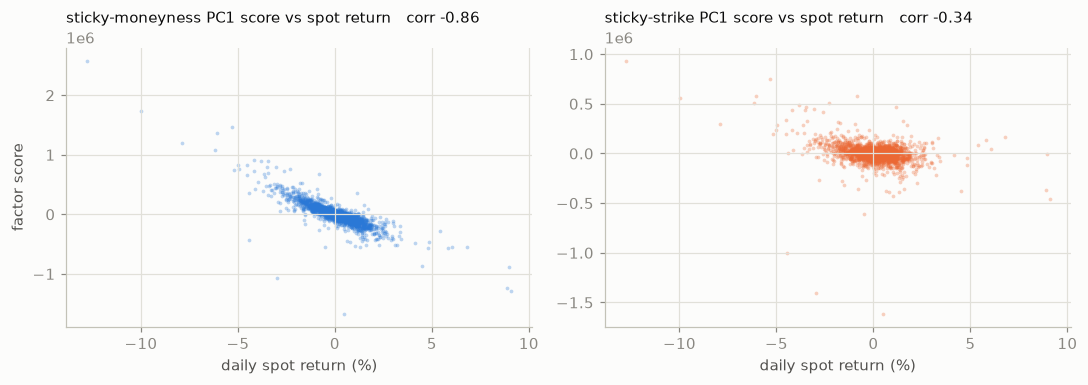

                  corr(f1, ret)  corr(f2, ret)  corr(f3, ret)  spot-return R² on f1..f3
sticky-moneyness         -0.856          0.083          0.008                     0.740
sticky-strike            -0.340         -0.283         -0.098                     0.205


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=False)
for ax, f, name, c in ((axes[0], f_mon, "sticky-moneyness", C_MON),
                       (axes[1], f_ss, "sticky-strike", C_SS)):
    r = np.corrcoef(f[normal, 0], ret[normal])[0, 1]
    ax.scatter(ret[normal] * 100, f[normal, 0], s=6, alpha=0.3, color=c, lw=0)
    ax.set_title(f"{name} PC1 score vs spot return   corr {r:+.2f}", loc="left", fontsize=10)
    ax.set_xlabel("daily spot return (%)")
axes[0].set_ylabel("factor score")
plt.tight_layout(); plt.show()

rows = {}
for name, f in (("sticky-moneyness", f_mon), ("sticky-strike", f_ss)):
    cs = [np.corrcoef(f[normal, i], ret[normal])[0, 1] for i in range(3)]
    beta, *_ = np.linalg.lstsq(f[normal, :3], ret[normal], rcond=None)
    r2 = 1 - (ret[normal] - f[normal, :3] @ beta).var() / ret[normal].var()
    rows[name] = cs + [r2]
tab = pd.DataFrame(rows, index=["corr(f1, ret)", "corr(f2, ret)", "corr(f3, ret)",
                                "spot-return R² on f1..f3"]).T
print(tab.round(3).to_string())

## Estimate quality against the fixed-strike vol target

The economic quantity both setups ultimately serve is the book's fixed-strike vol P&L ex the
anticipatable term-roll carry: `vol − vol_roll` (std $70k). Three estimators:

1. **moneyness PCA alone** — predicts the $150k surface move; against the $70k fixed-strike
   target it is not just noisy but *anti*-explanatory (R² ≈ −2.5). This is the sharp version of
   the "difference of two large numbers" concern: surface factors alone cannot hit this target.
2. **moneyness PCA + slide** — the pairing the book actually uses: the smile-delta/equity side
   hands the slide over. Not a cheat in historical VaR: the replayed spot move plus the
   previous-close smile determine slide almost exactly.
3. **sticky-strike PCA** — self-contained, slide inside the factors.

Sticky-strike is now **ahead of the paired setup at every k** (0.81 vs 0.77 at k=3) with a
higher ceiling (0.985 vs 0.955 at all 104 factors). This is a sampling-smoothness result, not
a pure coordinate result: with the old **bilinear** lookup the ranking was reversed at every k
(0.76 at k=3, ceiling 0.92) — the rescaled queries landed on the kinks of the piecewise-linear
surface, and the bracket-crossing samples read as pillar noise that PCA wastes capacity on.
The smooth interpolant removes that artifact, and what remains favors modeling the (smaller)
net fixed-strike move directly.

R² by factor count (columns 2-4 vs the fixed-strike target, normal days):
     mon vs vol_surface (own target)  mon alone vs fixed-strike  mon + slide  sticky-strike
k                                                                                          
1                             0.8889                    -2.9129       0.4862         0.5422
2                             0.9097                    -2.6890       0.5824         0.6353
3                             0.9503                    -2.4701       0.7701         0.8108
5                             0.9666                    -2.4572       0.8458         0.8559
10                            0.9817                    -2.5070       0.9153         0.9343
104                           0.9902                    -2.5194       0.9547         0.9852


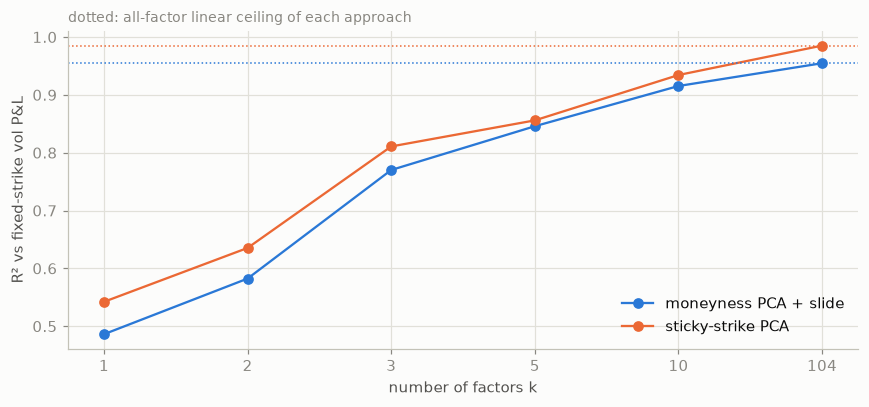

In [5]:
ks = [1, 2, 3, 5, 10, 104]
est_mon, _, _ = factor_vega_estimates(bucket_vega, dsigma, m_mon, ks)
est_ss, _, _ = factor_vega_estimates(bucket_vega, dsigma_ss, m_ss, ks)

def r2(t, e):
    return 1 - (t[normal] - e[normal]).var() / t[normal].var()

tab = pd.DataFrame({
    "mon vs vol_surface (own target)": [r2(t_mon, est_mon[k]) for k in ks],
    "mon alone vs fixed-strike": [r2(t_ss, est_mon[k]) for k in ks],
    "mon + slide": [r2(t_ss, est_mon[k] + slide) for k in ks],
    "sticky-strike": [r2(t_ss, est_ss[k]) for k in ks],
}, index=pd.Index(ks, name="k"))
print("R² by factor count (columns 2-4 vs the fixed-strike target, normal days):")
print(tab.round(4).to_string())

x = np.arange(len(ks))
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(x, tab["mon + slide"], "o-", color=C_MON, label="moneyness PCA + slide")
ax.plot(x, tab["sticky-strike"], "o-", color=C_SS, label="sticky-strike PCA")
for col, c in (("mon + slide", C_MON), ("sticky-strike", C_SS)):
    ax.axhline(tab[col].iloc[-1], color=c, ls=":", lw=1)
ax.set_xticks(x, [str(k) for k in ks])
ax.set_xlabel("number of factors k")
ax.set_ylabel("R² vs fixed-strike vol P&L")
ax.set_title("dotted: all-factor linear ceiling of each approach", loc="left", fontsize=9, color=MUT)
ax.legend()
plt.tight_layout(); plt.show()

## Where each ceiling comes from

At the all-factor limit each model is exactly its linear bucketed-vega estimate, so the gap to
the nonlinear target isolates what each setup gives up:

- **moneyness + slide**: gap std **$14.8k** — pure vega convexity (the bucketed identity
  `pl_vega_lin = bucket_vega · Δσ` is exact to 1e-9 in these coordinates), incurred on the
  *large* $150k surface move before the offsetting slide is added back.
- **sticky-strike**: gap std **$8.5k** — a small residual identity loss (the rescaled lookup
  m·S₀/S₁ sits between pillars and clamps at the 50/150 edges) plus convexity on the *net*
  $70k fixed-strike move. Linearizing the smaller combined move beats linearizing the two big
  offsetting pieces separately, which is why the self-contained ceiling is now higher. Both
  gaps still grow with the size of the spot move (corr of |gap| with |return| ≈ 0.5–0.6) —
  the days VaR cares about.

The base terms `bucket_vega·μ` are both economically negligible now (moneyness ≈ −$0.1k/day,
sticky-strike ≈ −$0.8k/day). Under the old bilinear sampling the sticky-strike mean ran
≈ **+$8.8k/day** (~$27M over the sample): linear interpolation overestimates a convex smile
between nodes, so every day's rescaled sample carried a positive bias that masqueraded as
skew-slide carry. The smooth interpolant removes it — a reminder that in these coordinates
the factor-model *mean* is exposed to sampling bias in a way fixed-pillar differences are not.

linear-limit gap std: moneyness $14,839   sticky-strike $8,494
base drift bucket_vega·μ: moneyness $-81/day   sticky-strike $-849/day


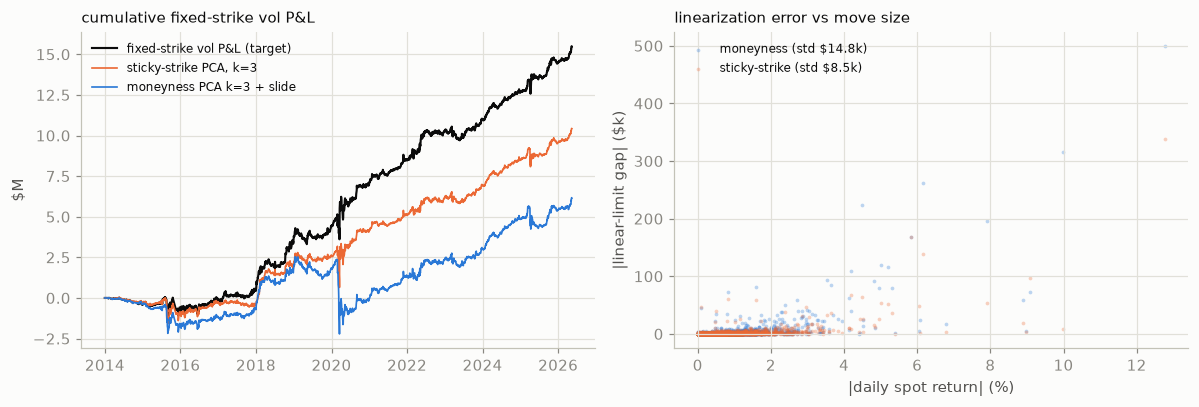

In [6]:
lin_mon, lin_ss = est_mon[104], est_ss[104]
gap_mon, gap_ss = t_mon - lin_mon, t_ss - lin_ss
print(f"linear-limit gap std: moneyness ${gap_mon[normal].std():,.0f}   "
      f"sticky-strike ${gap_ss[normal].std():,.0f}")
print(f"base drift bucket_vega·μ: moneyness ${(bucket_vega[normal] @ m_mon.mu).mean():,.0f}/day   "
      f"sticky-strike ${(bucket_vega[normal] @ m_ss.mu).mean():,.0f}/day")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
d = book.index
ax.plot(d, np.cumsum(t_ss) / 1e6, color=INK, lw=1.4, label="fixed-strike vol P&L (target)")
ax.plot(d, np.cumsum(est_ss[3]) / 1e6, color=C_SS, lw=1.1, label="sticky-strike PCA, k=3")
ax.plot(d, np.cumsum(est_mon[3] + slide) / 1e6, color=C_MON, lw=1.1, label="moneyness PCA k=3 + slide")
ax.set_title("cumulative fixed-strike vol P&L", loc="left", fontsize=10)
ax.set_ylabel("$M")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(np.abs(ret[normal]) * 100, np.abs(gap_mon[normal]) / 1e3, s=6, alpha=0.3,
           color=C_MON, lw=0, label=f"moneyness (std ${gap_mon[normal].std()/1e3:,.1f}k)")
ax.scatter(np.abs(ret[normal]) * 100, np.abs(gap_ss[normal]) / 1e3, s=6, alpha=0.3,
           color=C_SS, lw=0, label=f"sticky-strike (std ${gap_ss[normal].std()/1e3:,.1f}k)")
ax.set_xlabel("|daily spot return| (%)")
ax.set_ylabel("|linear-limit gap| ($k)")
ax.set_title("linearization error vs move size", loc="left", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Are the factors stable?

A worry with sticky-strike coordinates is that the Δσ depend on realized spot dynamics, so the
factors might drift with the spot-vol regime. Splitting the sample in half and refitting (same
weights) shows loading stability is in fact **comparable** — PC1 is rock solid in both systems
and the higher factors hold up similarly well:

In [7]:
idx = np.flatnonzero(normal)
h1 = np.zeros_like(normal); h1[idx[:len(idx) // 2]] = True
h2 = np.zeros_like(normal); h2[idx[len(idx) // 2:]] = True
rows = {}
for name, ds in (("sticky-moneyness", dsigma), ("sticky-strike", dsigma_ss)):
    a = fit_pca(ds, fit_mask=h1, weights=vega_w)
    b = fit_pca(ds, fit_mask=h2, weights=vega_w)
    rows[name] = [abs(np.corrcoef(a.components[i], b.components[i])[0, 1]) for i in range(3)]
tab = pd.DataFrame(rows, index=["PC1", "PC2", "PC3"]).T
print("|corr| of factor loadings, first half vs second half of the sample:")
print(tab.round(3).to_string())

|corr| of factor loadings, first half vs second half of the sample:
                    PC1    PC2    PC3
sticky-moneyness  1.000  0.985  0.961
sticky-strike     0.999  0.971  0.966


## Takeaways

- **The sticky-strike view directly addresses the "difference of two large numbers" concern**:
  the $70k fixed-strike target is modeled in its own coordinates, where near-ATM daily moves
  really are ~½ the fixed-moneyness ones and no $150k/$124k cancellation is involved.
- **Sampled with the smooth pricing interpolant it is also the better estimator at every k**
  (R² 0.81 vs 0.77 at k=3, ceiling 0.985 vs 0.955): linearizing the smaller net move beats
  linearizing the two big offsetting pieces separately. This reverses the bilinear-sampling
  result (0.76 at k=3, ceiling 0.92), where kinked bracket-crossing samples read as noise —
  the earlier deficit was an interpolation artifact, not a property of the coordinates.
- **Sticky-strike factors are far less spot-entangled** (top-3 scores span ~21% of spot-return
  variance vs ~74%; PC1 |corr| 0.34 vs 0.86). That is genuinely attractive for parametric
  stress design, where factors are shocked independently of spot. Historical simulation is
  indifferent — it replays spot and factor moves jointly.
- **Bookkeeping differs**: sticky-strike exposures pair with the plain BS delta rather than
  the smile delta the sequential book attribution hedges with, and its factor mean is exposed
  to sampling bias (the bilinear lookup faked ≈ +$8.8k/day of carry; cubic ≈ −$0.8k/day).
- **Decision**: sticky-strike is the headline framework — better estimator of the economic
  target at every k, higher ceiling, spot-orthogonal factors — with `vol − vol_roll` as the
  reported vol P&L quantity (the offsetting `vol_surface`/slide totals of the moneyness split
  are coordinate artifacts and are not quoted). The moneyness view survives inside the
  machinery (exact bucketed-vega identity, smile-delta attribution in `book.py`) and as this
  comparison.